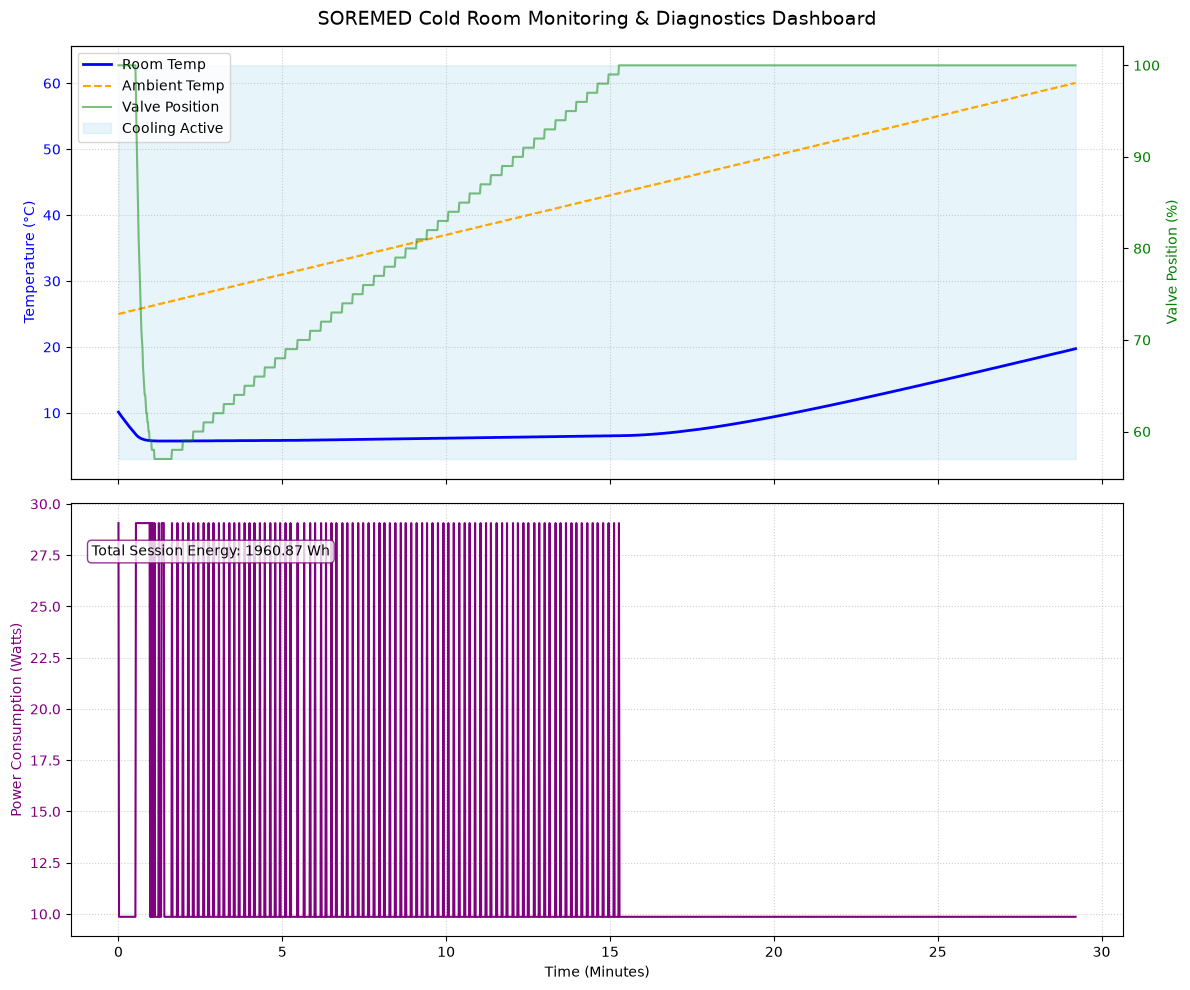

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. COLUMN DEFINITIONS FOR ESP32 TELEMETRY LOG
column_names = [
    "timestamp_ms", "room_temp", "ambient_temp", "humidity", 
    "leak_pct", "leak_alert", "cooling", "valve_pct", 
    "power_mW", "energy_mWh", "sensor_fault"
]

csv_file = "log1.csv"

# 2. DATA INGESTION & DATA CLEANING
# Read file without headers
df = pd.read_csv(csv_file, header=None, names=column_names)

# CRITICAL FIX: Convert timestamp to numeric and drop text/boot lines (e.g. "READY")
df['timestamp_ms'] = pd.to_numeric(df['timestamp_ms'], errors='coerce')
df = df.dropna(subset=['timestamp_ms'])

# Cast core tracking parameters to numeric to prevent downstream math errors
numeric_cols = ['room_temp', 'ambient_temp', 'valve_pct', 'power_mW', 'energy_mWh', 'leak_alert', 'cooling']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert timestamp column to relative minutes starting at 0
df['time_min'] = (df['timestamp_ms'] - df['timestamp_ms'].iloc[0]) / 60000.0


# 3. GRAPH CONFIGURATION & PLOTTING
# Setup a 2-row layout sharing the identical timeline X-axis
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# -------------------------------------------------------------------------
# ROW 1: ROOM METRICS (TEMPERATURES, VALVES, COOLING CYCLES, & LEAKS)
# -------------------------------------------------------------------------
ax1.set_title("SOREMED Cold Room Monitoring & Diagnostics Dashboard", fontsize=14, pad=15)

# Plot Primary Left Axis Data: Temperatures
line1 = ax1.plot(df['time_min'], df['room_temp'], label="Room Temp", color="blue", linewidth=2)
line2 = ax1.plot(df['time_min'], df['ambient_temp'], label="Ambient Temp", color="orange", linestyle="--")
ax1.set_ylabel("Temperature (°C)", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.grid(True, linestyle=":", alpha=0.6)

# Plot Secondary Right Axis Data: Valve Adjustments
ax2 = ax1.twinx()
line3 = ax2.plot(df['time_min'], df['valve_pct'], label="Valve Position", color="green", alpha=0.5)
ax2.set_ylabel("Valve Position (%)", color="green")
ax2.tick_params(axis='y', labelcolor="green")

# Highlight Active Cooling Phases (Light Blue Shading Overlay)
ax1.fill_between(df['time_min'], ax1.get_ylim()[0], ax1.get_ylim()[1], 
                 where=(df['cooling'] == 1), color='skyblue', alpha=0.2)

# Highlight Detected Leak Windows (Red 'X' Flags)
leaks = df[df['leak_alert'] == 1]
if not leaks.empty:
    ax1.scatter(leaks['time_min'], leaks['room_temp'], color='red', marker='X', s=100, zorder=5)
    print(f"⚠️ DASHBOARD ALERT: {len(leaks)} total leak instances caught inside this dataset.")

# Construct Unified Dashboard Legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]

# Add custom visual elements to legend matching the chart overlays
lines.append(Patch(color='skyblue', alpha=0.2))
labels.append("Cooling Active")

if not leaks.empty:
    lines.append(Line2D([0], [0], marker='X', color='red', linestyle='', markersize=10))
    labels.append("Leak Triggered")

ax1.legend(lines, labels, loc='upper left')


# -------------------------------------------------------------------------
# ROW 2: ELECTRICAL CONSUMPTION DETAILS
# -------------------------------------------------------------------------
# Convert power draw metrics from mW to standard Watts
ax3.plot(df['time_min'], df['power_mW'] / 1000.0, label="Power (W)", color="purple", linewidth=1.5)
ax3.set_xlabel("Time (Minutes)")
ax3.set_ylabel("Power Consumption (Watts)", color="purple")
ax3.tick_params(axis='y', labelcolor="purple")
ax3.grid(True, linestyle=":", alpha=0.6)

# Overlay Total Calculated Operational Energy Footprint (Wh)
total_energy_wh = df['energy_mWh'].max() / 1000.0 if not df['energy_mWh'].empty else 0
ax3.annotate(f"Total Session Energy: {total_energy_wh:.2f} Wh", 
             xy=(0.02, 0.88), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="purple", lw=1, alpha=0.8))

# 4. RENDER PRESENTATION
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. COLUMN DEFINITIONS FOR ESP32 TELEMETRY LOG
column_names = [
    "timestamp_ms", "room_temp", "ambient_temp", "humidity", 
    "leak_pct", "leak_alert", "cooling", "valve_pct", 
    "power_mW", "energy_mWh", "sensor_fault"
]

csv_file = "log2.csv"

# 2. DATA INGESTION & DATA CLEANING
# Read file without headers
df = pd.read_csv(csv_file, header=None, names=column_names)

# CRITICAL FIX: Convert timestamp to numeric and drop text/boot lines (e.g. "READY")
df['timestamp_ms'] = pd.to_numeric(df['timestamp_ms'], errors='coerce')
df = df.dropna(subset=['timestamp_ms'])

# Cast core tracking parameters to numeric to prevent downstream math errors
numeric_cols = ['room_temp', 'ambient_temp', 'valve_pct', 'power_mW', 'energy_mWh', 'leak_alert', 'cooling']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert timestamp column to relative minutes starting at 0
df['time_min'] = (df['timestamp_ms'] - df['timestamp_ms'].iloc[0]) / 60000.0


# 3. GRAPH CONFIGURATION & PLOTTING
# Setup a 2-row layout sharing the identical timeline X-axis
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# -------------------------------------------------------------------------
# ROW 1: ROOM METRICS (TEMPERATURES, VALVES, COOLING CYCLES, & LEAKS)
# -------------------------------------------------------------------------
ax1.set_title("SOREMED Cold Room Monitoring & Diagnostics Dashboard", fontsize=14, pad=15)

# Plot Primary Left Axis Data: Temperatures
line1 = ax1.plot(df['time_min'], df['room_temp'], label="Room Temp", color="blue", linewidth=2)
line2 = ax1.plot(df['time_min'], df['ambient_temp'], label="Ambient Temp", color="orange", linestyle="--")
ax1.set_ylabel("Temperature (°C)", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.grid(True, linestyle=":", alpha=0.6)

# Plot Secondary Right Axis Data: Valve Adjustments
ax2 = ax1.twinx()
line3 = ax2.plot(df['time_min'], df['valve_pct'], label="Valve Position", color="green", alpha=0.5)
ax2.set_ylabel("Valve Position (%)", color="green")
ax2.tick_params(axis='y', labelcolor="green")

# Highlight Active Cooling Phases (Light Blue Shading Overlay)
ax1.fill_between(df['time_min'], ax1.get_ylim()[0], ax1.get_ylim()[1], 
                 where=(df['cooling'] == 1), color='skyblue', alpha=0.2)

# Highlight Detected Leak Windows (Red 'X' Flags)
leaks = df[df['leak_alert'] == 1]
if not leaks.empty:
    ax1.scatter(leaks['time_min'], leaks['room_temp'], color='red', marker='X', s=100, zorder=5)
    print(f"⚠️ DASHBOARD ALERT: {len(leaks)} total leak instances caught inside this dataset.")

# Construct Unified Dashboard Legend
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]

# Add custom visual elements to legend matching the chart overlays
lines.append(Patch(color='skyblue', alpha=0.2))
labels.append("Cooling Active")

if not leaks.empty:
    lines.append(Line2D([0], [0], marker='X', color='red', linestyle='', markersize=10))
    labels.append("Leak Triggered")

ax1.legend(lines, labels, loc='upper left')


# -------------------------------------------------------------------------
# ROW 2: ELECTRICAL CONSUMPTION DETAILS
# -------------------------------------------------------------------------
# Convert power draw metrics from mW to standard Watts
ax3.plot(df['time_min'], df['power_mW'] / 1000.0, label="Power (W)", color="purple", linewidth=1.5)
ax3.set_xlabel("Time (Minutes)")
ax3.set_ylabel("Power Consumption (Watts)", color="purple")
ax3.tick_params(axis='y', labelcolor="purple")
ax3.grid(True, linestyle=":", alpha=0.6)

# Overlay Total Calculated Operational Energy Footprint (Wh)
total_energy_wh = df['energy_mWh'].max() / 1000.0 if not df['energy_mWh'].empty else 0
ax3.annotate(f"Total Session Energy: {total_energy_wh:.2f} Wh", 
             xy=(0.02, 0.88), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="purple", lw=1, alpha=0.8))

# 4. RENDER PRESENTATION
plt.tight_layout()
plt.show()
